<a href="https://colab.research.google.com/github/Etsuko2003/deeplearning-project/blob/main/projet_deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!export KAGGLE_API_TOKEN=KGAT_6d04d5a1ed2decbe42a79e386b7c8eca

In [9]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub

kagglehub.login()


Kaggle credentials set.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

jonestor_engie_data_path = kagglehub.dataset_download('jonestor/engie-data')
jonestor_engie_data_x_path = kagglehub.dataset_download('jonestor/engie-data-x')

print('Data source import complete.')


# Importation

In [ ]:
import os
import numpy as np
import pandas as pd

import keras
from keras import layers, models, callbacks

import keras_tuner as kt

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Chargement et prétraitement des données

In [ ]:
X_df_init = pd.read_csv("/kaggle/input/engie-data-x/engie_X.csv", sep=";")

X_df_init.head()

,ID,MAC_CODE,Date_time,Pitch_angle,Pitch_angle_min,Pitch_angle_max,Pitch_angle_std,Hub_temperature,Hub_temperature_min,Hub_temperature_max,...,Rotor_speed,Rotor_speed_min,Rotor_speed_max,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_min,Rotor_bearing_temperature_max,Rotor_bearing_temperature_std,Absolute_wind_direction_c,Nacelle_angle_c
0,1,WT3,1.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,294.19000,294.23999
1,2,WT3,2.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,297.82999,294.23999
2,3,WT3,3.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,322.20999,294.23999
3,4,WT3,4.0,92.470001,92.470001,92.470001,0.0,6.97,6.7,7.0,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,318.69000,294.23999
4,5,WT3,5.0,92.470001,92.470001,92.470001,0.0,6.93,6.0,7.0,...,0.0,0.0,0.0,0.0,2.4,2.4,2.5,0.0,314.89001,294.23999


In [ ]:
Y_df_init = pd.read_csv("/kaggle/input/engie-data/engie_Y.csv", sep=";")

Y_df_init.head()

,ID,TARGET
0,1,-0.703
1,2,-0.747
2,3,-0.791
3,4,-0.736
4,5,-1.055


In [ ]:
X_df_init.shape, Y_df_init.shape # 617386

((617386, 78), (617386, 2))

In [ ]:
X_df_init.describe().round(2)

,ID,Date_time,Pitch_angle,Pitch_angle_min,Pitch_angle_max,Pitch_angle_std,Hub_temperature,Hub_temperature_min,Hub_temperature_max,Hub_temperature_std,...,Rotor_speed,Rotor_speed_min,Rotor_speed_max,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_min,Rotor_bearing_temperature_max,Rotor_bearing_temperature_std,Absolute_wind_direction_c,Nacelle_angle_c
count,617386.00,617386.00,617386.00,617386.00,617386.00,617386.00,617386.00,617386.00,617386.00,617386.00,...,617386.00,617386.00,617386.00,617386.00,617386.00,617386.00,617386.00,617386.00,617314.00,617314.00
mean,308693.50,79862.86,13.01,11.80,14.55,0.95,19.15,18.94,19.36,0.11,...,10.12,8.98,11.21,0.60,28.42,28.32,28.50,0.05,174.83,175.54
std,178224.13,45185.11,27.24,27.05,28.01,4.21,6.60,6.63,6.60,0.16,...,5.73,5.44,6.00,0.76,7.26,7.27,7.29,0.13,96.09,96.77
min,1.00,1.00,-156.18,-179.57,-146.28,0.00,-4.00,-5.00,-3.00,0.00,...,0.00,0.00,0.00,0.00,-5.20,-5.20,-5.10,0.00,0.00,0.00
25%,154347.25,41154.00,-1.00,-1.01,-1.00,0.00,14.00,14.00,14.00,0.00,...,8.79,8.70,8.87,0.12,25.60,25.50,25.70,0.02,80.67,79.66
50%,308693.50,80145.00,-1.00,-1.00,-1.00,0.00,19.99,19.20,20.00,0.00,...,11.16,9.72,12.54,0.36,29.60,29.50,29.70,0.04,191.74,193.27
75%,463039.75,119014.00,5.57,-0.98,15.90,0.00,24.00,24.00,24.00,0.21,...,14.87,12.95,16.76,0.82,33.01,32.90,33.10,0.07,245.81,248.03
max,617386.00,157680.00,156.82,175.93,175.93,94.77,37.08,37.00,38.00,1.24,...,17.18,17.11,19.71,8.47,67.67,53.50,393.80,98.57,360.00,360.00


In [ ]:
print(X_df_init.columns)

Index(['ID', 'MAC_CODE', 'Date_time', 'Pitch_angle', 'Pitch_angle_min',
       'Pitch_angle_max', 'Pitch_angle_std', 'Hub_temperature',
       'Hub_temperature_min', 'Hub_temperature_max', 'Hub_temperature_std',
       'Generator_converter_speed', 'Generator_converter_speed_min',
       'Generator_converter_speed_max', 'Generator_converter_speed_std',
       'Generator_speed', 'Generator_speed_min', 'Generator_speed_max',
       'Generator_speed_std', 'Generator_bearing_1_temperature',
       'Generator_bearing_1_temperature_min',
       'Generator_bearing_1_temperature_max',
       'Generator_bearing_1_temperature_std',
       'Generator_bearing_2_temperature',
       'Generator_bearing_2_temperature_min',
       'Generator_bearing_2_temperature_max',
       'Generator_bearing_2_temperature_std', 'Generator_stator_temperature',
       'Generator_stator_temperature_min', 'Generator_stator_temperature_max',
       'Generator_stator_temperature_std', 'Gearbox_bearing_1_temperature',
    

In [ ]:
X_df_indexed = X_df_init.set_index(keys="ID")
Y_df_indexed = Y_df_init.set_index(keys="ID")

In [ ]:
X_df_indexed.head()

,MAC_CODE,Date_time,Pitch_angle,Pitch_angle_min,Pitch_angle_max,Pitch_angle_std,Hub_temperature,Hub_temperature_min,Hub_temperature_max,Hub_temperature_std,...,Rotor_speed,Rotor_speed_min,Rotor_speed_max,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_min,Rotor_bearing_temperature_max,Rotor_bearing_temperature_std,Absolute_wind_direction_c,Nacelle_angle_c
ID,,,,,,,,,,,,,,,,,,,,,
1,WT3,1.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,294.19000,294.23999
2,WT3,2.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,297.82999,294.23999
3,WT3,3.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,322.20999,294.23999
4,WT3,4.0,92.470001,92.470001,92.470001,0.0,6.97,6.7,7.0,0.02,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,318.69000,294.23999
5,WT3,5.0,92.470001,92.470001,92.470001,0.0,6.93,6.0,7.0,0.17,...,0.0,0.0,0.0,0.0,2.4,2.4,2.5,0.0,314.89001,294.23999


In [ ]:
Y_df_indexed.head()

,TARGET
ID,
1,-0.703
2,-0.747
3,-0.791
4,-0.736
5,-1.055


In [ ]:
X_df_indexed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 617386 entries, 1 to 617386
Data columns (total 77 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   MAC_CODE                             617386 non-null  object 
 1   Date_time                            617386 non-null  float64
 2   Pitch_angle                          617386 non-null  float64
 3   Pitch_angle_min                      617386 non-null  float64
 4   Pitch_angle_max                      617386 non-null  float64
 5   Pitch_angle_std                      617386 non-null  float64
 6   Hub_temperature                      617386 non-null  float64
 7   Hub_temperature_min                  617386 non-null  float64
 8   Hub_temperature_max                  617386 non-null  float64
 9   Hub_temperature_std                  617386 non-null  float64
 10  Generator_converter_speed            609322 non-null  float64
 11  Generator_converte

In [ ]:
columns_with_na = X_df_indexed.columns[X_df_indexed.isna().any()].tolist()

In [ ]:
len(columns_with_na)

14

Nous avons 14 colonnes ayant des valeurs manquantes

In [ ]:
nb_rows_with_nan = X_df_indexed.isna().any(axis=1).sum()
int(nb_rows_with_nan), round(int(nb_rows_with_nan)/len(engieX_df), 2)

(109416, 0.18)

Nous avons **109416** lignes avec des valeurs manquantes. Soit **0.18%** de tout l'ensemble des échantillons.

La stratégie pour la suite sera de supprimer ces lignes.

In [ ]:
X_df_without_nan = X_df_indexed.dropna(axis=0)
X_df = X_df_without_nan.drop("Date_time", axis=1)

In [ ]:
Y_df = Y_df_indexed.loc[X_df.index]

In [ ]:
X_df.head()

,MAC_CODE,Pitch_angle,Pitch_angle_min,Pitch_angle_max,Pitch_angle_std,Hub_temperature,Hub_temperature_min,Hub_temperature_max,Hub_temperature_std,Generator_converter_speed,...,Rotor_speed,Rotor_speed_min,Rotor_speed_max,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_min,Rotor_bearing_temperature_max,Rotor_bearing_temperature_std,Absolute_wind_direction_c,Nacelle_angle_c
ID,,,,,,,,,,,,,,,,,,,,,
1,WT3,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,3.38,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,294.19000,294.23999
2,WT3,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,3.56,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,297.82999,294.23999
3,WT3,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,0.00,3.51,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,322.20999,294.23999
4,WT3,92.470001,92.470001,92.470001,0.0,6.97,6.7,7.0,0.02,4.06,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,318.69000,294.23999
5,WT3,92.470001,92.470001,92.470001,0.0,6.93,6.0,7.0,0.17,3.61,...,0.0,0.0,0.0,0.0,2.4,2.4,2.5,0.0,314.89001,294.23999


In [ ]:
X_df.describe().round(2)

,Pitch_angle,Pitch_angle_min,Pitch_angle_max,Pitch_angle_std,Hub_temperature,Hub_temperature_min,Hub_temperature_max,Hub_temperature_std,Generator_converter_speed,Generator_converter_speed_min,...,Rotor_speed,Rotor_speed_min,Rotor_speed_max,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_min,Rotor_bearing_temperature_max,Rotor_bearing_temperature_std,Absolute_wind_direction_c,Nacelle_angle_c
count,507970.00,507970.00,507970.00,507970.00,507970.00,507970.00,507970.00,507970.00,507970.00,507970.00,...,507970.00,507970.00,507970.00,507970.00,507970.00,507970.00,507970.00,507970.00,507970.00,507970.00
mean,12.92,11.73,14.46,0.93,18.98,18.78,19.19,0.11,1076.53,958.22,...,10.23,9.09,11.30,0.59,28.31,28.21,28.39,0.05,174.04,174.87
std,27.33,27.15,28.08,4.15,6.41,6.43,6.41,0.16,602.26,572.49,...,5.75,5.46,6.01,0.76,7.21,7.22,7.24,0.14,94.43,95.00
min,-156.18,-179.57,-146.28,0.00,-4.00,-5.00,-3.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,-5.20,-5.20,-5.10,0.00,0.00,0.00
25%,-1.00,-1.01,-1.00,0.00,14.00,14.00,14.00,0.00,926.50,917.95,...,8.80,8.71,8.92,0.12,25.60,25.50,25.70,0.02,81.70,81.20
50%,-1.00,-1.00,-1.00,0.00,19.79,19.00,20.00,0.00,1186.70,1036.08,...,11.27,9.82,12.66,0.35,29.48,29.40,29.60,0.04,190.91,192.54
75%,4.70,-0.98,13.99,0.00,24.00,24.00,24.00,0.21,1581.59,1381.84,...,15.05,13.13,16.92,0.81,32.81,32.75,32.90,0.07,243.35,245.22
max,156.82,175.93,175.93,94.77,37.00,37.00,37.00,1.24,1806.56,1801.91,...,17.18,17.11,19.71,8.43,67.67,53.50,393.80,98.57,360.00,360.00


In [ ]:
X_df.shape, Y_df.shape

((507970, 76), (507970, 1))

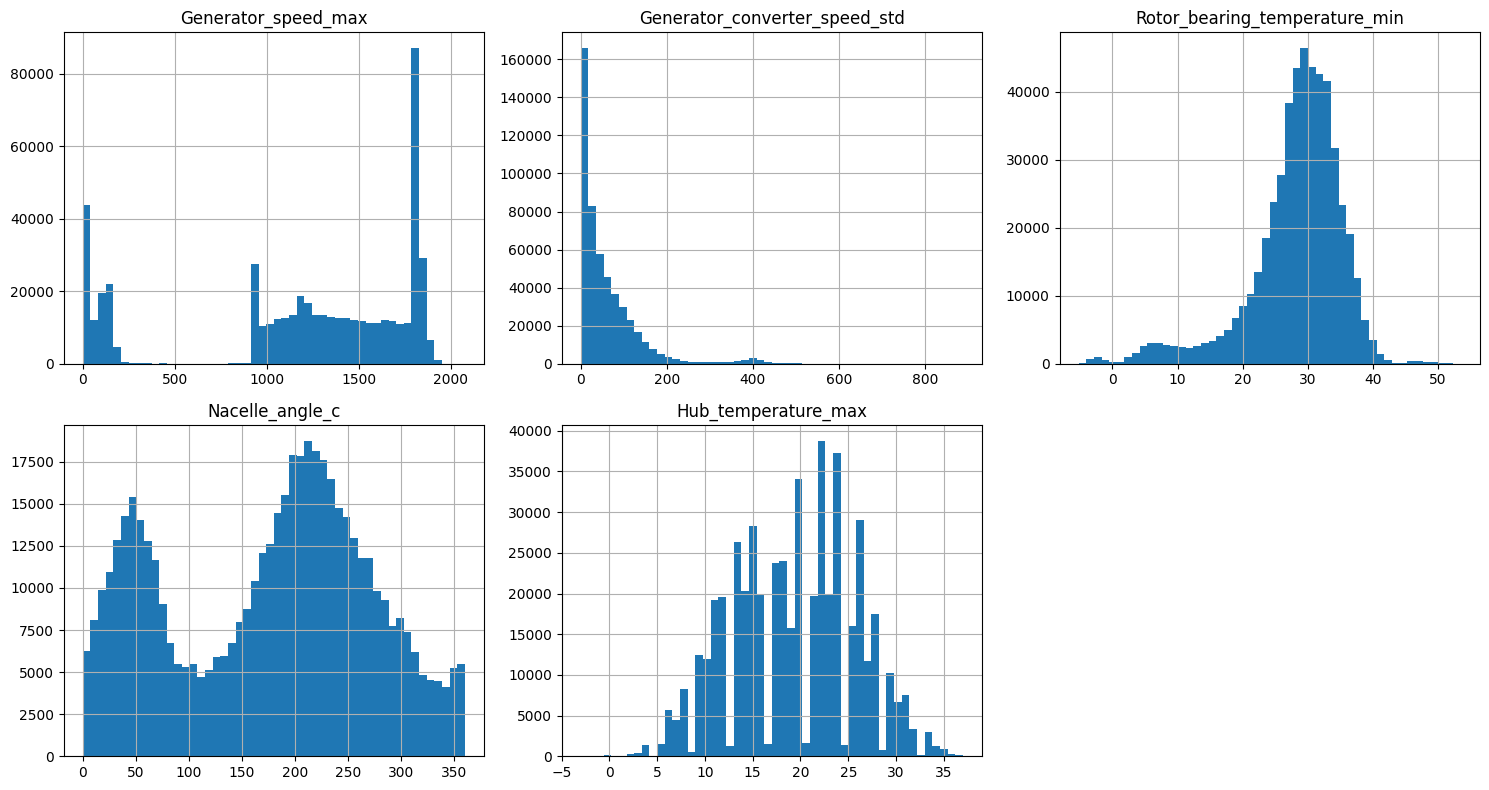

In [ ]:
cols = X_df.select_dtypes(include="number").columns
random_cols = np.random.choice(cols, size=5, replace=False)
X_df[random_cols].hist(
    bins=50,
    figsize=(15, 8),
    layout=(2, 3)
)

plt.tight_layout()
plt.show()

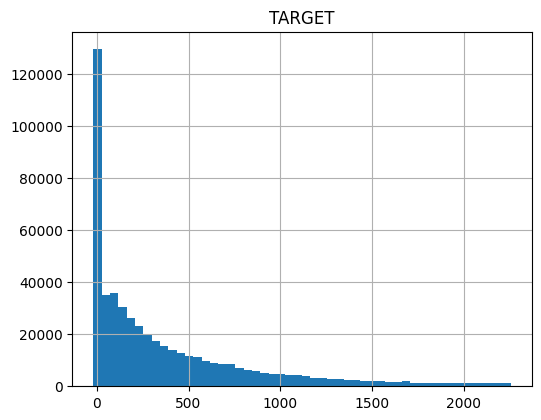

In [ ]:
Y_df.hist(
    bins=50,
    figsize=(15, 8),
    layout=(2, 3)
)

plt.tight_layout()
plt.show()

## Valeurs aberrantes

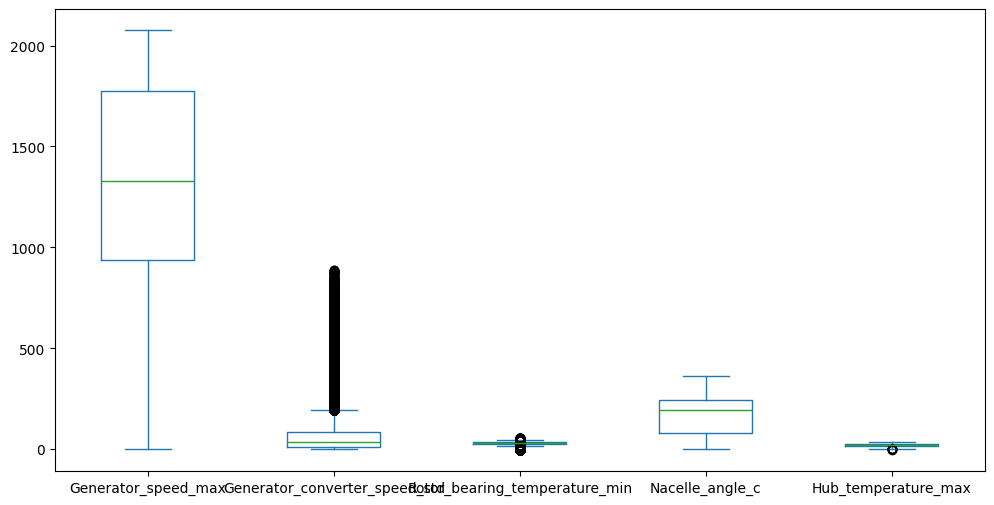

In [ ]:
X_df[random_cols].plot(kind="box", figsize=(12, 6))
plt.show()

In [ ]:
median = X_df.select_dtypes(include="number").median()
mad = (X_df - median).abs().median()

outliers_per_col = (X_df - median).abs() > 3 * mad).sum()

In [ ]:
outliers_per_col.sort_values(ascending=False)

Hub_temperature_std          228650
Pitch_angle_max              199162
Pitch_angle                  180117
Pitch_angle_min              119493
Nacelle_temperature_std      100979
                              ...  
Absolute_wind_direction           0
Absolute_wind_direction_c         0
Nacelle_angle_c                   0
MAC_CODE                          0
Nacelle_angle                     0
Length: 76, dtype: int64

## Colonnes à variance faible
Vérifions si il existe des colonnes ayant une faible variance

In [ ]:
cv = X_df.std(numeric_only=True) / X_df.mean(numeric_only=True).abs()
low_variance_cols = cv[cv < 0.01].index.tolist()
len(low_variance_cols)

0

Nous n'avons **aucune** covariable à faible variance

## Corrélation matrice

In [ ]:
num_cols = X_df.select_dtypes(include="number").columns
X_num = X_df[num_cols]

<Figure size 1200x1000 with 0 Axes>

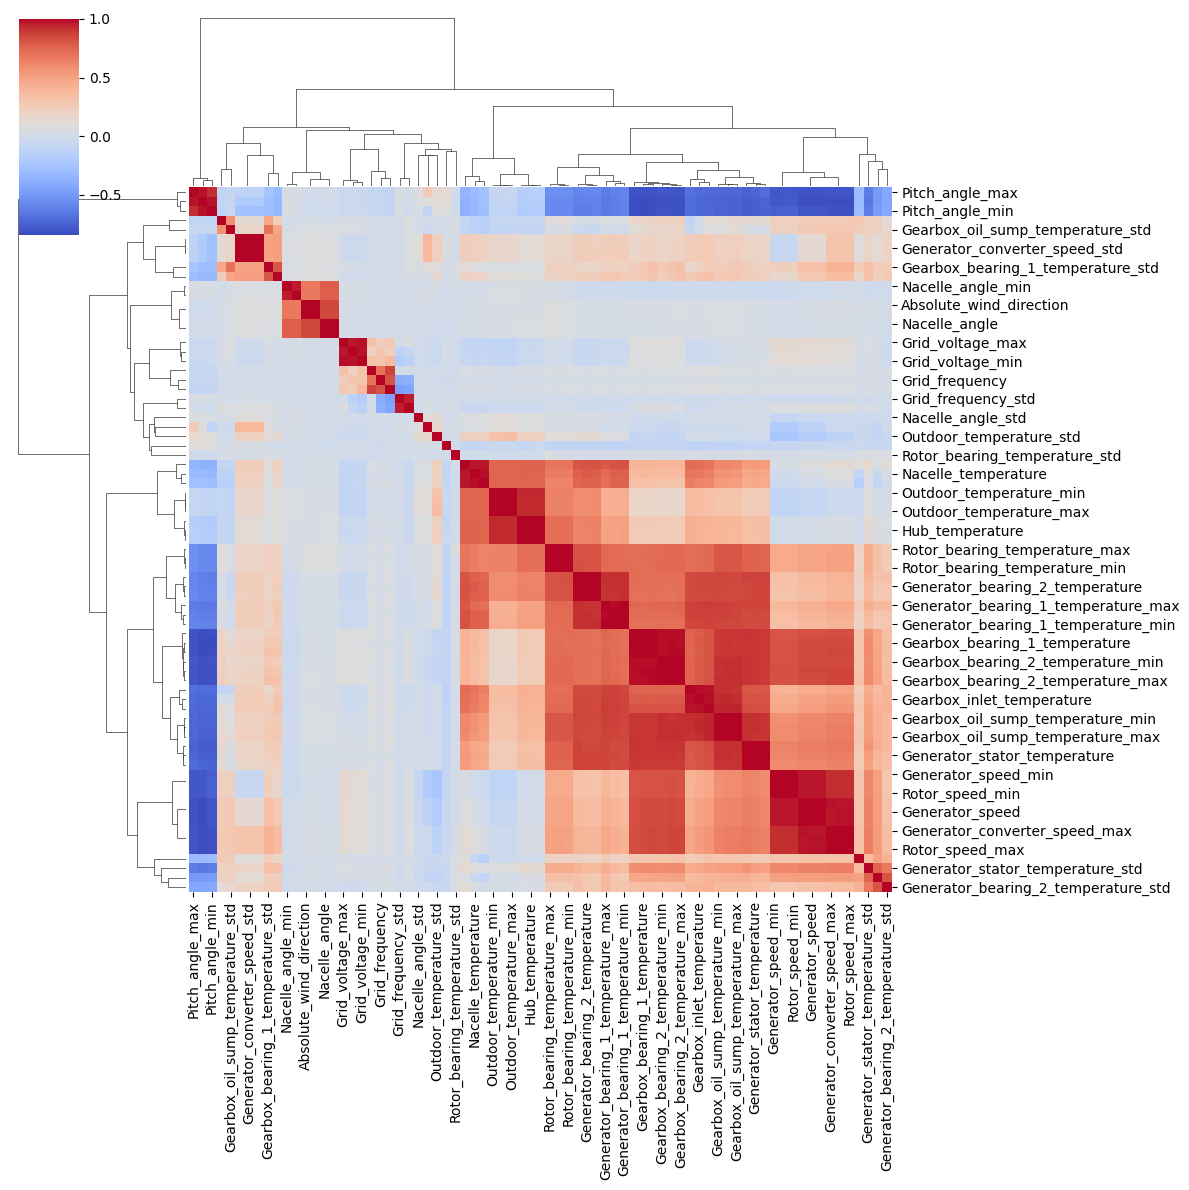

In [ ]:
threshold = 0.75  # par exemple |corr| > 0.5
corr = X_num.corr()

# Ne garder que les corrélations fortes
strong_corr = corr[(corr.abs() > threshold) & (corr.abs() < 1.0)]  # exclure la diagonale

plt.figure(figsize=(12, 10))
sns.clustermap(corr, cmap="coolwarm", figsize=(12, 12), annot=False)
plt.show()

In [ ]:
target_corr = X_num.corrwith(Y_df.iloc[:, 0])
target_corr.sort_values(key=abs, ascending=False).tail(20)

Pitch_angle_std                       -0.040845
Grid_frequency_min                     0.025595
Grid_frequency_max                     0.022720
Nacelle_angle_std                     -0.022024
Gearbox_bearing_2_temperature_std      0.021700
Grid_frequency                         0.021493
Absolute_wind_direction_c              0.020901
Absolute_wind_direction                0.020901
Generator_bearing_1_temperature_max    0.017599
Generator_bearing_1_temperature_min   -0.016987
Gearbox_inlet_temperature_min          0.016300
Nacelle_angle_c                        0.013511
Nacelle_angle                          0.013508
Generator_bearing_2_temperature_std    0.012007
Hub_temperature_std                    0.011597
Grid_frequency_std                    -0.010810
Nacelle_angle_min                     -0.009645
Nacelle_angle_max                     -0.007648
Generator_bearing_1_temperature       -0.001922
Rotor_bearing_temperature_std         -0.001455
dtype: float64

In [ ]:
cat_cols = X_df.select_dtypes(include="object").columns.tolist()
cat_cols

['MAC_CODE']

In [ ]:
target_corr = X_num.corrwith(Y_df.iloc[:, 0])
threshold = 0.1  # tu peux mettre 0.05 pour être un peu plus strict
selected_features = target_corr[abs(target_corr) > threshold].index.tolist()



X_df = X_df[selected_features+cat_cols]

print(f"Colonnes conservées : {len(selected_features)} sur {X_num.shape[1]}")


Colonnes conservées : 44 sur 75


## Traitement de la variable catégorielle

In [ ]:
X_df["MAC_CODE"].value_counts()

MAC_CODE
WT3    139941
WT2    123183
WT1    122986
WT4    121860
Name: count, dtype: int64

In [ ]:
import pandas as pd

def time_series_machine_split(X_df, Y_df, machine_col="MAC_CODE", train_ratio=0.7, valid_ratio=0.15):
    """
    Split X and Y for time series regression per machine, preserving temporal order.
    """

    X_train_list = []
    X_val_list = []
    X_test_list = []

    y_train_list = []
    y_val_list = []
    y_test_list = []

    for machine in X_df[machine_col].unique():
        X_machine = X_df[X_df[machine_col] == machine]
        y_machine = Y_df.loc[X_machine.index]
        n = len(X_machine)

        train_end = int(train_ratio * n)
        val_end = train_end + int(valid_ratio * n)

        X_train_list.append(X_machine.iloc[:train_end])
        y_train_list.append(y_machine.iloc[:train_end])

        X_val_list.append(X_machine.iloc[train_end:val_end])
        y_val_list.append(y_machine.iloc[train_end:val_end])

        X_test_list.append(X_machine.iloc[val_end:])
        y_test_list.append(y_machine.iloc[val_end:])

    # Concaténer toutes les machines
    X_train = pd.concat(X_train_list)
    X_val = pd.concat(X_val_list)
    X_test = pd.concat(X_test_list)

    y_train = pd.concat(y_train_list)
    y_val = pd.concat(y_val_list)
    y_test = pd.concat(y_test_list)

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = time_series_machine_split(X_df, Y_df, machine_col="MAC_CODE", train_ratio=0.7, valid_ratio=0.15)

In [ ]:
X_train = pd.get_dummies(X_train, columns=["MAC_CODE"], drop_first=True)
X_val = pd.get_dummies(X_val, columns=["MAC_CODE"]).reindex(columns=X_train.columns, fill_value=0)
X_test = pd.get_dummies(X_test, columns=["MAC_CODE"]).reindex(columns=X_train.columns, fill_value=0)
X_train.columns

Index(['Pitch_angle', 'Pitch_angle_min', 'Pitch_angle_max',
       'Generator_converter_speed', 'Generator_converter_speed_min',
       'Generator_converter_speed_max', 'Generator_speed',
       'Generator_speed_min', 'Generator_speed_max',
       'Generator_bearing_1_temperature_std', 'Generator_stator_temperature',
       'Generator_stator_temperature_min', 'Generator_stator_temperature_max',
       'Generator_stator_temperature_std', 'Gearbox_bearing_1_temperature',
       'Gearbox_bearing_1_temperature_min',
       'Gearbox_bearing_1_temperature_max',
       'Gearbox_bearing_1_temperature_std', 'Gearbox_bearing_2_temperature',
       'Gearbox_bearing_2_temperature_min',
       'Gearbox_bearing_2_temperature_max', 'Gearbox_inlet_temperature_std',
       'Gearbox_oil_sump_temperature', 'Gearbox_oil_sump_temperature_min',
       'Gearbox_oil_sump_temperature_max', 'Gearbox_oil_sump_temperature_std',
       'Nacelle_temperature', 'Nacelle_temperature_min',
       'Nacelle_temperature_m

## Normalisation

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_norm = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_val_norm = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)
X_test_norm = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [ ]:
X_train_norm.shape

(355578, 48)

# Construction du Réseau de Neurones

In [ ]:
def build_model():
    model = models.Sequential()
    models.add(layers.Dense(64, activation="relu", input_shape=(X_train)))